# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

Question 1 response
1. Adding a penalty  means the model is “charged” for having large coefficients. So instead of just minimizing error, it also tries to keep the coefficients small. This helps prevent overfitting because the model won’t rely too heavily on any one variable. As stated in the notes, the penalty is "paid" by alpha.
2. Regularization provides a way to control the bias-variance trade-off by adjusting the value of alpha. When alpha is small, the model behaves more like regular linear regression (low bias but high variance). As alpha increases, the model shrinks the coefficients (high bias but low variance).
3. The difference is that Ridge regression shrinks coefficients toward zero but keeps all variables in the model. LASSO can shrink some coefficients all the way to zero, so it actually removes variables. Because of this, LASSO can be used for variable selection because Ridge just makes the coefficients smaller.
4. We usually scale variables using z-scores so they all have the same scale. This is important because the penalty depends on the size of the coefficients. If variables are on different scales, some would be penalized more than others so scaling makes sure all variables are treated equally.
5. Alpha is selected using cross-validation. Different values of alpha are tried and the one that gives the lowest error on validation data is picked. A grid for alpha values are selected and for each alpha, k-fCV is used to pick the coefficients which minimize MSE(b)+alphab on the training folds. Then the mean/median value is picked and picked across the grid.
6. No because we care about how well the model predicts new data, not how big the coefficients are. The penalty is only used during training to control the model itself, notfor evaluating the cross validated MSE.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [30]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

In [31]:
# Question 2
#2.1
cars_df = pd.read_csv('./data/cars_hw.csv')
cars_df["Age"] = 2026 - cars_df["Make_Year"]
print(cars_df.head())
#third degree expansion
X = cars_df[["Mileage_Run", "Age"]]
expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(X)
poly_names = expander.get_feature_names_out()
# z-score normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  Age  
0  657000    9  
1  682000   10  
2  793000    7  
3  414000    9  
4  515000    9  


In [32]:
# 2.2
y = cars_df["Price"]
linear_model = LinearRegression()
linear_model = linear_model.fit(X_scaled, y)
coefs = linear_model.coef_
pd.DataFrame({
    "variable": poly_names,
    "coefficient": coefs })

# The sign for Mileage_Run interaction with age is negative. The table shows that the coefficient is negative.

,variable,coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


In [33]:
# 2.3
alpha_grid = np.logspace(1, 3, 20)
lasso_model = LassoCV(cv=20, alphas=alpha_grid, max_iter=10000)
lasso_model = lasso_model.fit(X_scaled, y)

#establish alpha star
alpha_star = lasso_model.alpha_
print(alpha_star)

pd.DataFrame({
    "variable": poly_names,
    "coefficient": lasso_model.coef_
})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977691506.578125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283106767.5625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706961927.5469, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objec

88.58667904100822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.695e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(


,variable,coefficient
0,Mileage_Run,7.789506e+05
1,Age,-1.337436e+05
2,Mileage_Run^2,-2.006015e+05
3,Mileage_Run Age,-1.323307e+06
4,Age^2,0.000000e+00
5,Mileage_Run^3,-4.246012e+04
6,Mileage_Run^2 Age,2.705049e+05
7,Mileage_Run Age^2,5.428505e+05
8,Age^3,1.334198e+04


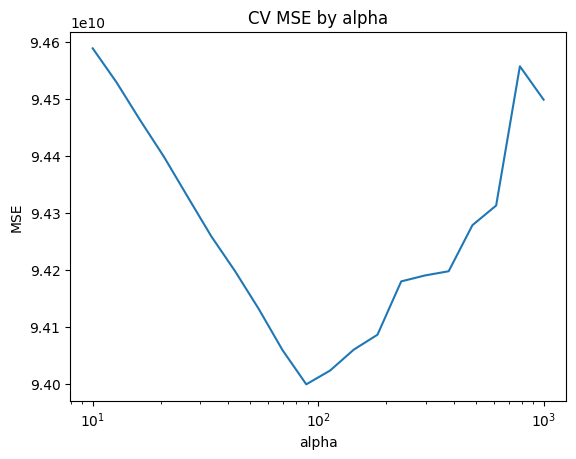

In [34]:
#2.4
mse_mean = lasso_model.mse_path_.mean(axis=1)
#plt plot
plt.plot(lasso_model.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('CV MSE by alpha')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.410e+10, tolerance: 1.316e

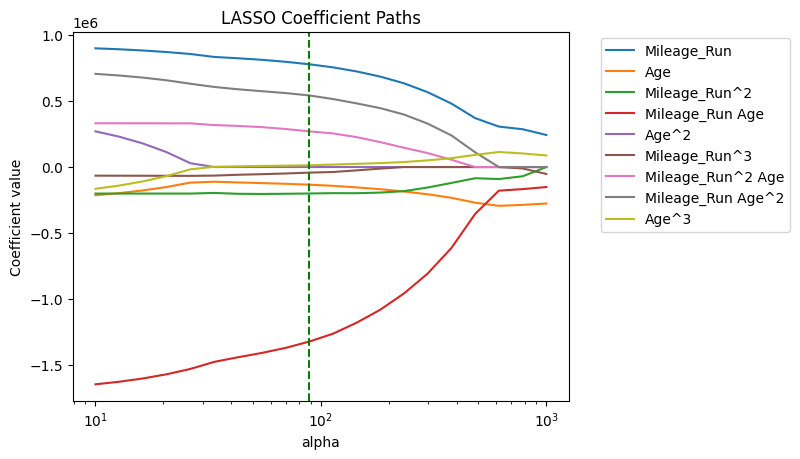

In [35]:
#2.5
#alpha grid and lasso model
alpha_grid = np.logspace(1, 3, 20)
coefs = []

for alpha in alpha_grid:
    model_lasso = Lasso(alpha=alpha, max_iter=10000)
    model_lasso = model_lasso.fit(X_scaled, y)
    coefs.append(model_lasso.coef_)

coefs = np.array(coefs)
var_names = poly_names

#making the graph
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=var_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [36]:
# 2.6
# wanted to find a way to calculate the coefficient for eprcent in next written responses so found how to do it (also same for 3.6)
linear_coefs = linear_model.coef_
pd.DataFrame({
    "variable": poly_names,
    "linear": linear_coefs,
    "lasso": lasso_model.coef_
})
#finding prop
np.mean(lasso_model.coef_ == 0)

np.float64(0.1111111111111111)

2.6
Features selected are Mileage_Run, Age, Mileage_Run^2, Mileage_Run and Age interaction, Mileage_Run^3, Mileage_Run^2 and Age interaction, Mileage_Run x Age^2, and Age^3. The feature set to zero is Age^2. This means that the proportion is 1/9 so 0.11. This is also shown by the code above to double check the math.

2.7
The LASSO coefficients are smaller in magnitude than the linear regression. Age^2 was the one feature that was removed since it was zero. The model is generaly the same as it kept the same sign but smaller in magnitude.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [37]:
# 3.1
heartfailure_df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
heartfailure_df.head()
#third degree expansion
X = heartfailure_df[["age", "ejection_fraction", "serum_creatinine"]]
expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(X)
poly_names = expander.get_feature_names_out()
# z-score normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
#covariate matrix
X_categorical = heartfailure_df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
expander_categorical = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_categorical_matrix = expander_categorical.fit_transform(X_categorical)
categorical_vars = expander_categorical.get_feature_names_out()
X = np.concatenate([X_scaled, X_categorical_matrix], axis=1)
feature_names = np.concatenate([poly_names, categorical_vars])
print(X)

[[ 1.19294523 -1.53055953  0.49005699 ...  0.          0.
   0.        ]
 [-0.49127928 -0.00707675 -0.28455235 ...  0.          0.
   0.        ]
 [ 0.35083298 -1.53055953 -0.09090002 ...  0.          0.
   0.        ]
 ...
 [-1.33339153  1.85495776 -0.57503085 ...  0.          0.
   0.        ]
 [-1.33339153 -0.00707675  0.00592615 ...  0.          0.
   0.        ]
 [-0.9123354   0.58538877  0.19957848 ...  0.          0.
   0.        ]]


In [38]:
#3.2
y = heartfailure_df["DEATH_EVENT"]
linear_model = LinearRegression()
linear_model = linear_model.fit(X, y)
linear_coefs = linear_model.coef_
pd.DataFrame({
    "variable": feature_names,
    "coefficient": linear_coefs
})

,variable,coefficient
0,age,1.539156
1,ejection_fraction,-2.192494
2,serum_creatinine,-0.853588
3,age^2,-3.678654
4,age ejection_fraction,-0.600918
5,age serum_creatinine,1.841563
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
9,age^3,1.993135


There are conterintuitive sign patterns with age and age^2 because age is positive and age^2 is negative which does not make much sense. Additionally, age^3 is positive. Also, creatinine is usually an indication of heart failure but there is a negative coefficient which does not seem intuitive.

Including higher-order powers would allow the model to look at nonlinear relationships which would make the results more broadened/realistic. The conterintuitive sides are due to multicollinearity, so this would likely resolve/better it.

In [39]:
#3.3
alpha_grid = np.logspace(-5, 5, 30)
lasso_model = LassoCV(cv=20, alphas=alpha_grid, max_iter=100000)
lasso_model = lasso_model.fit(X, y)
alpha = lasso_model.alpha_
print(alpha)
pd.DataFrame({
    "variable": feature_names,
    "coefficient": lasso_model.coef_
})

0.005736152510448681


,variable,coefficient
0,age,-0.000000
1,ejection_fraction,-0.329656
2,serum_creatinine,0.116875
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.117992


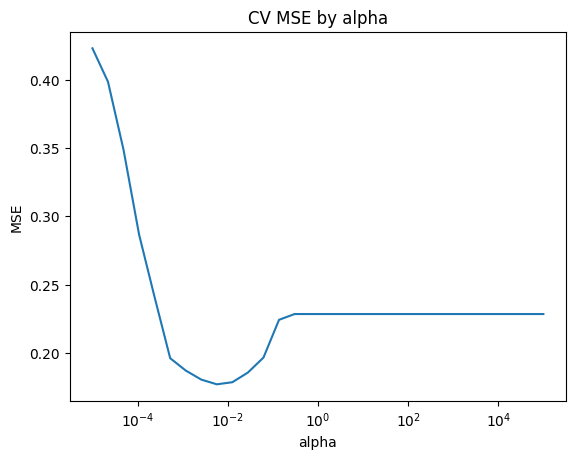

In [40]:
#3.4
mse_mean = lasso_model.mse_path_.mean(axis=1)

plt.plot(lasso_model.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('CV MSE by alpha')
plt.show()

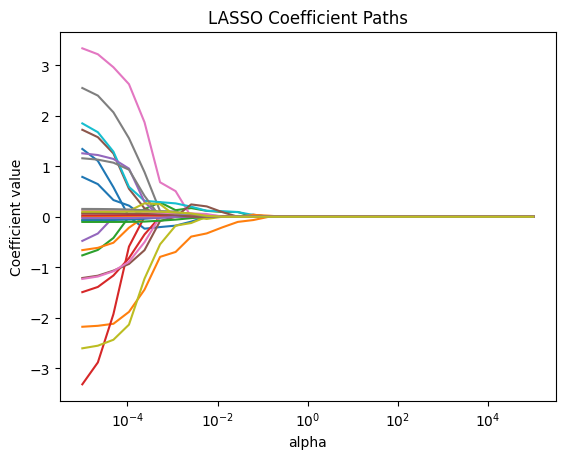

In [41]:
#3.5
alpha_grid = np.logspace(-5, 5, 30)
coefs = []

for alpha in alpha_grid:
    model_lasso = Lasso(alpha=alpha, max_iter=100000)
    model_lasso = model_lasso.fit(X, y)
    coefs.append(model_lasso.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [42]:
#3.6
pd.DataFrame({
    "variable": feature_names,
    "linear": linear_coefs,
    "lasso": lasso_model.coef_
})
np.mean(lasso_model.coef_ == 0)

np.float64(0.5862068965517241)

LASSO sets some coefficients equal to zero. Using the coefficient from above, about 58.6% of the coefficients are zero, so a lot of the features are removed and only the important ones stay in the model. Compared to linear regression, the LASSO coefficients are smaller because the model is basically “penalized” for having large coefficients. Some coefficients also change sign because LASSO removes correlated variables, so the remaining ones take on more of the effect. The sign patterns from LASSO make more sense than the linear regression ones. In the linear model, some signs looked weird because the polynomial and interaction terms are highly correlated, which makes the coefficients unstable. This relates to the bias-variance trade-off. Linear regression has low bias but high variance, so the coefficients can vary a lot. LASSO adds some bias by shrinking the coefficients, but it reduces variance, which makes the model more stable and easier to interpret.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Question 4 response
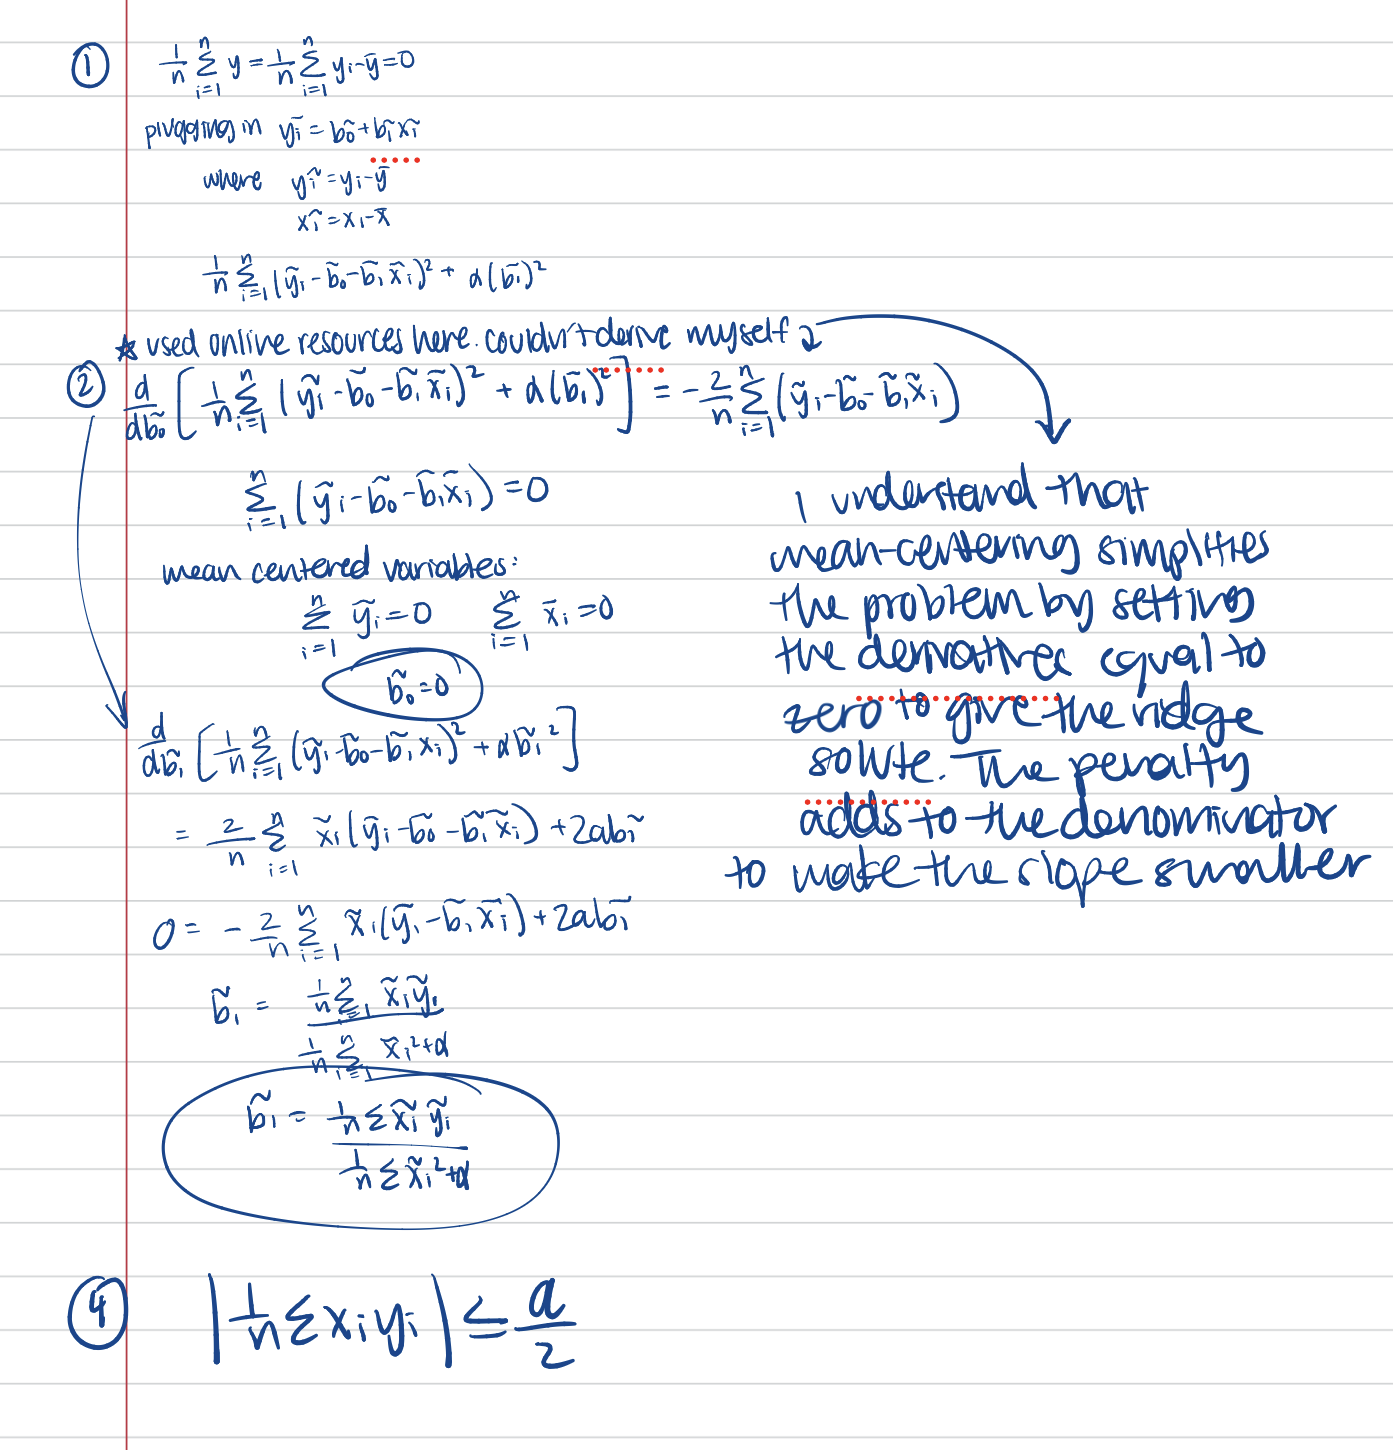
1. The objective function is the MSE plus the ridge penalty. (picture)
2. picture
3. As alpha increases, the slope approaches zero because the denominator of the function increases.
4. You can't differentiate the b1 at zero so then you can't derive the penalty. LASSO sets the slope to zero in this case. It is optimal to set b1=0 when x and y relationship is not strong enough. Since the penalty is too big, then the slope is set to zero (picture).
